In [1]:
import os
import cv2
import math
import random
import numpy as np
import datetime as dt
import tensorflow as tf
from collections import deque
import matplotlib.pyplot as plt

# from moviepy.editor import *
# %matplotlib inline

from sklearn.model_selection import train_test_split

from tensorflow.keras.layers import *
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import plot_model

In [2]:
seed_constant = 27
np.random.seed(seed_constant)
random.seed(seed_constant)
tf.random.set_seed(seed_constant)

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("matthewjansen/ucf101-action-recognition")

print("Path to dataset files:", path)

100%|██████████| 6.53G/6.53G [01:10<00:00, 99.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4


Processing video: /root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/train/PlayingCello/v_PlayingCello_g07_c03.avi
Processing video: /root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/train/CricketShot/v_CricketShot_g02_c04.avi
Processing video: /root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/train/TennisSwing/v_TennisSwing_g04_c02.avi
Processing video: /root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/train/Punch/v_Punch_g18_c05.avi
Processing video: /root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/train/ShavingBeard/v_ShavingBeard_g19_c01.avi


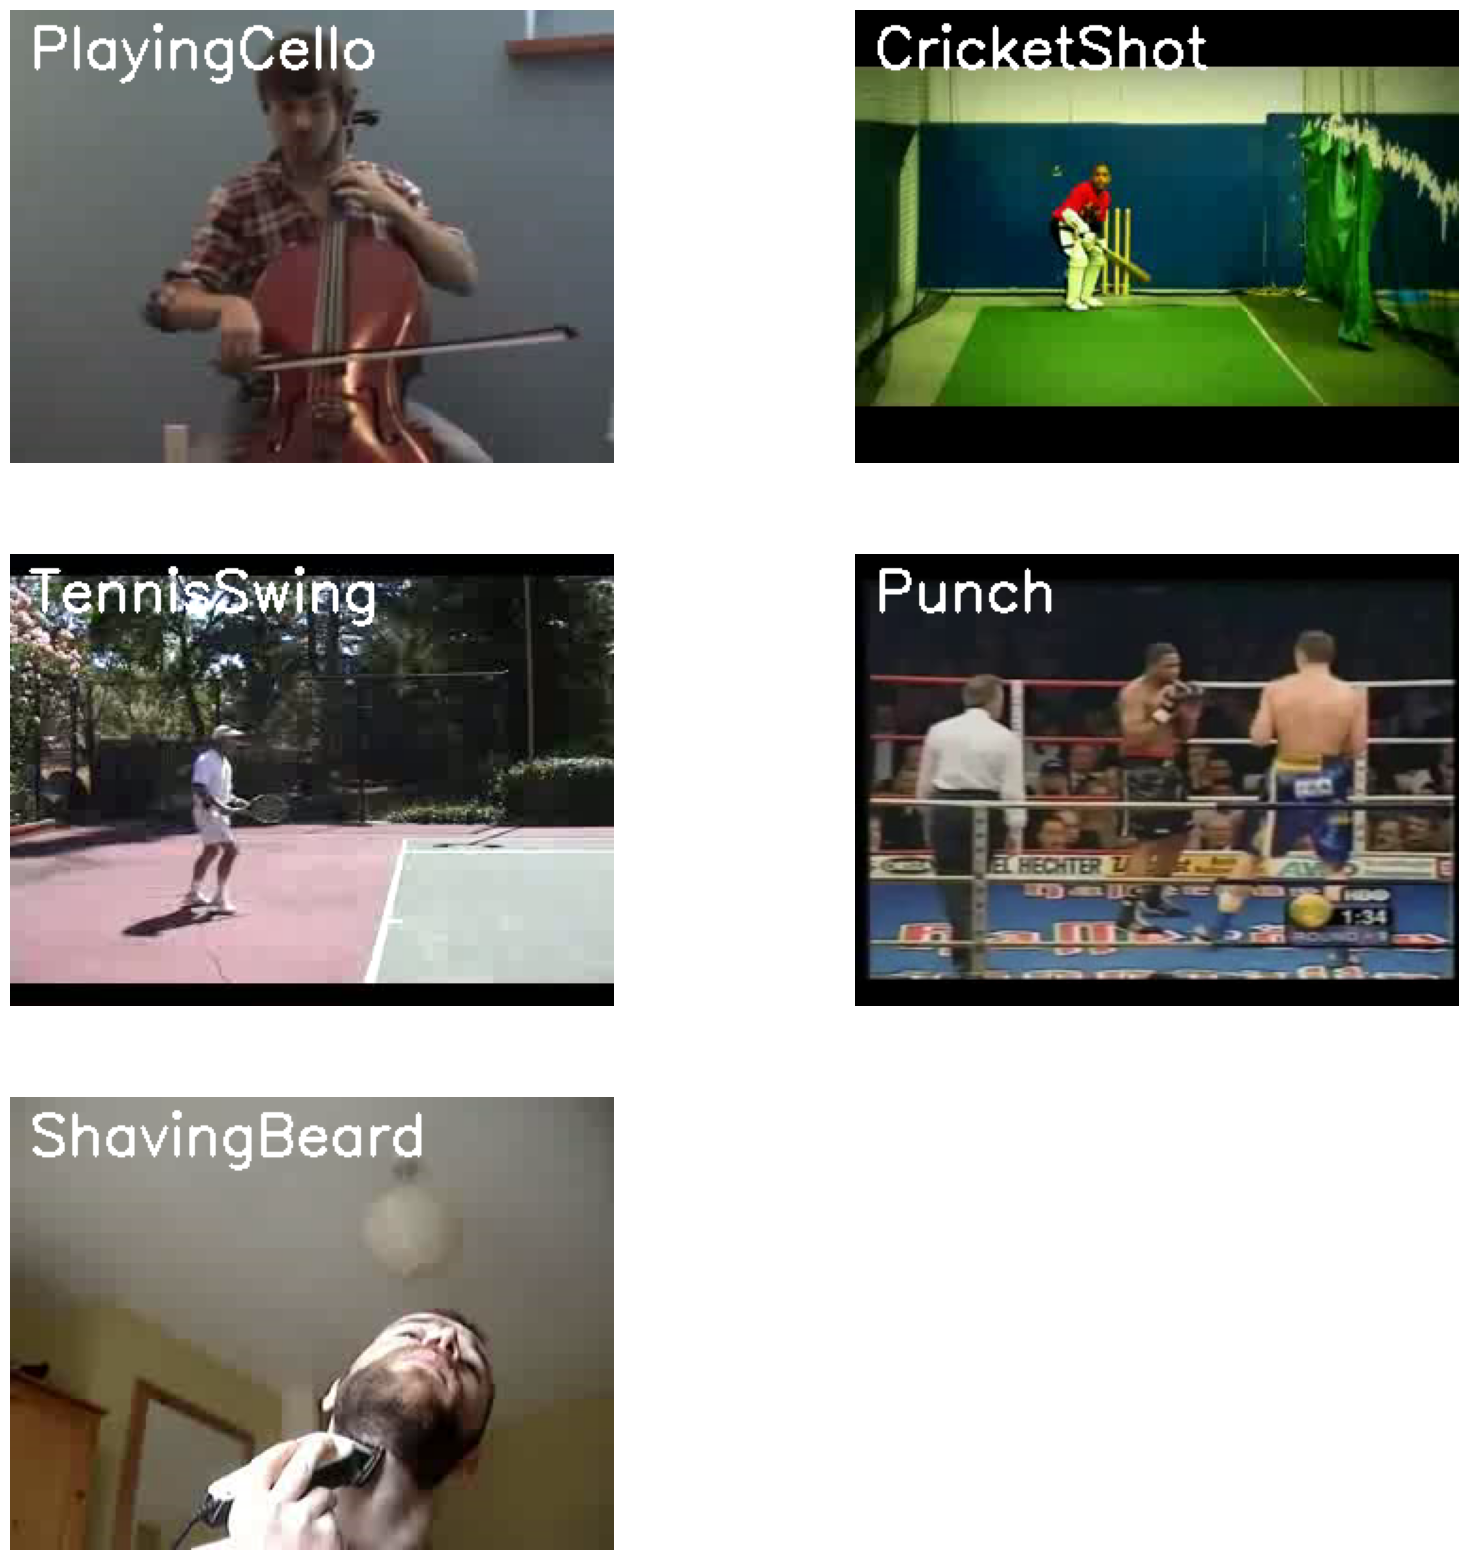

In [4]:

# Specify the top 5 classes
top_5_classes = ["CricketShot", "PlayingCello", "Punch", "ShavingBeard", "TennisSwing"]

# Path to the training dataset
train_path = os.path.join(path, 'train')

# Filter to include only the top 5 classes
all_classes_names = [cls for cls in os.listdir(train_path) if cls in top_5_classes]

# Ensure there are classes available
if not all_classes_names:
    print("No classes found in the specified path.")
else:
    # Create a Matplotlib figure and specify the size of the figure
    plt.figure(figsize=(20, 20))

    # Sample all available classes (or fewer if less than 5)
    sample_size = len(all_classes_names)
    random_range = random.sample(range(len(all_classes_names)), sample_size)

    # Iterate through the selected classes
    for counter, random_index in enumerate(random_range, 1):
        selected_class_name = all_classes_names[random_index]

        # List all video files for the selected class
        video_files_names_list = os.listdir(os.path.join(train_path, selected_class_name))

        # Randomly select a video file
        selected_video_file_name = random.choice(video_files_names_list)

        # Construct the full path to the video file
        video_file_path = os.path.join(train_path, selected_class_name, selected_video_file_name)
        print(f"Processing video: {video_file_path}")

        # Initialize a VideoCapture object to read the video file
        video_reader = cv2.VideoCapture(video_file_path)

        # Check if the video was successfully opened
        if not video_reader.isOpened():
            print(f"Error opening video file: {video_file_path}")
            continue

        # Read the first frame of the video file
        success, bgr_frame = video_reader.read()

        # Release the VideoCapture object
        video_reader.release()

        # Check if the frame was successfully read
        if not success:
            print(f"Error reading frame from video file: {video_file_path}")
            continue

        # Convert the frame from BGR to RGB format
        rgb_frame = cv2.cvtColor(bgr_frame, cv2.COLOR_BGR2RGB)

        # Add the class name as a label on the frame
        cv2.putText(rgb_frame, selected_class_name, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

        # Display the frame in a grid
        plt.subplot(3, 2, counter)
        plt.imshow(rgb_frame)
        plt.axis('off')

    # Show the grid of images
    plt.show()


In [41]:
train_path

'/root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/train'

In [30]:
train_path = os.path.join(path, 'train')
print("Train Path:", train_path)

# Check if the train directory exists
if not os.path.exists(train_path):
    print("Train directory does not exist. Check your dataset structure.")
else:
    # List all available classes
    all_classes = os.listdir(train_path)
    print("Available Classes:", all_classes)

    # Check for CricketShot
    cricket_shot_path = os.path.join(train_path, 'CricketShot')
    if os.path.exists(cricket_shot_path):
        print("CricketShot Path:", cricket_shot_path)
        print("Files in CricketShot:", os.listdir(cricket_shot_path))
    else:
        print("CricketShot class directory does not exist.")

Train Path: /root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/train
Available Classes: ['MoppingFloor', 'Archery', 'HorseRace', 'Shotput', 'SkateBoarding', 'Skijet', 'HulaHoop', 'FrontCrawl', 'PlayingTabla', 'JumpRope', 'Diving', 'SumoWrestling', 'StillRings', 'PoleVault', 'BlowDryHair', 'Kayaking', 'Mixing', 'MilitaryParade', 'YoYo', 'HorseRiding', 'IceDancing', 'Swing', 'JumpingJack', 'ApplyLipstick', 'BodyWeightSquats', 'HandstandPushups', 'Rowing', 'Skiing', 'Knitting', 'Bowling', 'SalsaSpin', 'SkyDiving', 'ApplyEyeMakeup', 'PushUps', 'CricketBowling', 'BlowingCandles', 'RopeClimbing', 'Billiards', 'HandstandWalking', 'Haircut', 'LongJump', 'FrisbeeCatch', 'Biking', 'ThrowDiscus', 'JavelinThrow', 'BoxingSpeedBag', 'BreastStroke', 'PlayingPiano', 'TableTennisShot', 'Rafting', 'WallPushups', 'ParallelBars', 'GolfSwing', 'PlayingGuitar', 'TrampolineJumping', 'HammerThrow', 'Punch', 'BrushingTeeth', 'TennisSwing', 'Basketball', 'BabyCrawling', 'FloorGym

In [6]:
# Define paths
train_path = os.path.join(path, 'train')
top_5_classes = ["CricketShot", "PlayingCello", "Punch", "ShavingBeard", "TennisSwing"]

# Verify dataset structure
if not os.path.exists(train_path):
    raise FileNotFoundError(f"Train directory not found at {train_path}. Ensure dataset is structured correctly.")
else:
    print(f"Train directory exists at: {train_path}")

Train directory exists at: /root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/train


In [7]:
import os
import cv2
import numpy as np

def frames_extraction(video_path, sequence_length, image_width, image_height):
    '''
    This function will extract the required frames from a video after resizing and normalizing them.
    Args:
        video_path: The path of the video in the disk, whose frames are to be extracted.
        sequence_length: The number of frames to extract from the video.
        image_width: The width to which each frame should be resized.
        image_height: The height to which each frame should be resized.
    Returns:
        frames_list: A list containing the resized and normalized frames of the video.
    '''
    frames_list = []
    video_reader = cv2.VideoCapture(video_path)

    if not video_reader.isOpened():
        print(f"Error: Could not open video file '{video_path}'.")
        return frames_list

    video_frames_count = int(video_reader.get(cv2.CAP_PROP_FRAME_COUNT))
    skip_frames_window = max(int(video_frames_count / sequence_length), 1)

    for frame_counter in range(sequence_length):
        video_reader.set(cv2.CAP_PROP_POS_FRAMES, frame_counter * skip_frames_window)
        success, frame = video_reader.read()

        if not success:
            print(f"Error: Could not read frame {frame_counter} from video '{video_path}'.")
            break

        resized_frame = cv2.resize(frame, (image_width, image_height))
        normalized_frame = resized_frame / 255.0  # Normalize pixel values to [0, 1]
        frames_list.append(normalized_frame)

    video_reader.release()
    return frames_list

def create_dataset(dataset_dir, classes_list, sequence_length, image_width, image_height):
    '''
    This function will extract the data of the selected classes and create the required dataset.
    Args:
        dataset_dir: The directory where the video dataset is located.
        classes_list: The list of class names to process.
        sequence_length: The number of frames to extract from each video.
        image_width: The width to which each frame should be resized.
        image_height: The height to which each frame should be resized.
    Returns:
        features: A numpy array containing the extracted frames of the videos.
        labels: A numpy array containing the indexes of the classes associated with the videos.
        video_files_paths: A list containing the paths of the videos in the disk.
    '''
    features = []
    labels = []
    video_files_paths = []

    for class_index, class_name in enumerate(classes_list):
        print(f'Extracting data for class: {class_name}')
        class_dir = os.path.join(dataset_dir, class_name)

        if not os.path.isdir(class_dir):
            print(f"Error: Directory '{class_dir}' does not exist.")
            continue

        files_list = [f for f in os.listdir(class_dir) if f.endswith(('.mp4', '.avi', '.mov', '.mkv'))]

        if not files_list:
            print(f"Error: No video files found in class '{class_name}'.")
            continue

        for file_name in files_list:
            video_file_path = os.path.join(class_dir, file_name)

            if not os.path.isfile(video_file_path):
                print(f"Error: File '{video_file_path}' does not exist.")
                continue

            frames = frames_extraction(video_file_path, sequence_length, image_width, image_height)

            if len(frames) == sequence_length:
                features.append(frames)
                labels.append(class_index)
                video_files_paths.append(video_file_path)
            else:
                print(f"Skipping video '{file_name}' due to insufficient frames.")

    features = np.asarray(features)
    labels = np.array(labels)

    print(f"Total videos processed: {len(video_files_paths)}")
    print(f"Feature shape: {features.shape}, Labels shape: {labels.shape}")

    return features, labels, video_files_paths


In [8]:
# Define constants
IMAGE_WIDTH = 64
IMAGE_HEIGHT = 64
SEQUENCE_LENGTH = 20
DATASET_DIR = '/root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/train'  # Path to the dataset directory
CLASSES_LIST = ['CricketShot', 'PlayingCello', 'Punch', 'ShavingBeard', 'TennisSwing']

# Create the dataset
features, labels, video_files_paths = create_dataset(DATASET_DIR, CLASSES_LIST, SEQUENCE_LENGTH, IMAGE_WIDTH, IMAGE_HEIGHT)

# Check if dataset creation was successful
print("Dataset created successfully!")

Extracting data for class: CricketShot
Extracting data for class: PlayingCello
Extracting data for class: Punch
Extracting data for class: ShavingBeard
Extracting data for class: TennisSwing


In [9]:
one_hot_encoded_labels = to_categorical(labels)

In [10]:
features_train, features_test, labels_train, labels_test = train_test_split(features, one_hot_encoded_labels,
                                                                            test_size = 0.25, shuffle = True,
                                                                            random_state = seed_constant)

In [11]:
def create_convlstm_model():
    '''
    This function will construct the required convlstm model.
    Returns:
        model: It is the required constructed convlstm model.
    '''

    # We will use a Sequential model for model construction
    model = Sequential()

    # Define the Model Architecture.
    ########################################################################################################################

    model.add(ConvLSTM2D(filters = 4, kernel_size = (3, 3), activation = 'tanh',data_format = "channels_last",
                         recurrent_dropout=0.2, return_sequences=True, input_shape = (SEQUENCE_LENGTH,
                                                                                      IMAGE_HEIGHT, IMAGE_WIDTH, 3)))

    model.add(MaxPooling3D(pool_size=(1, 2, 2), padding='same', data_format='channels_last'))
    model.add(TimeDistributed(Dropout(0.2)))

    model.add(ConvLSTM2D(filters = 8, kernel_size = (3, 3), activation = 'tanh', data_format = "channels_last",
                         recurrent_dropout=0.2, return_sequences=True))

    model.add(MaxPooling3D(pool_size=(1, 2, 2), padding='same', data_format='channels_last'))
    model.add(TimeDistributed(Dropout(0.2)))

    model.add(ConvLSTM2D(filters = 14, kernel_size = (3, 3), activation = 'tanh', data_format = "channels_last",
                         recurrent_dropout=0.2, return_sequences=True))

    model.add(MaxPooling3D(pool_size=(1, 2, 2), padding='same', data_format='channels_last'))
    model.add(TimeDistributed(Dropout(0.2)))

    model.add(ConvLSTM2D(filters = 16, kernel_size = (3, 3), activation = 'tanh', data_format = "channels_last",
                         recurrent_dropout=0.2, return_sequences=True))

    model.add(MaxPooling3D(pool_size=(1, 2, 2), padding='same', data_format='channels_last'))
    #model.add(TimeDistributed(Dropout(0.2)))

    model.add(Flatten())

    model.add(Dense(len(CLASSES_LIST), activation = "softmax"))

    ########################################################################################################################

    # Display the models summary.
    model.summary()

    # Return the constructed convlstm model.
    return model

In [12]:
# Construct the required convlstm model.
convlstm_model = create_convlstm_model()

# Display the success message.
print("Model Created Successfully!")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv_lstm2d (ConvLSTM2D)             │ (None, 20, 62, 62, 4)       │           1,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling3d (MaxPooling3D)         │ (None, 20, 31, 31, 4)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed (TimeDistributed)   │ (None, 20, 31, 31, 4)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_1 (ConvLSTM2D)           │ (None, 20, 29, 29, 8)       │           3,488 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling3d_1 (MaxPooling3D)       │ (None, 20, 15, 15, 8)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_1 (TimeDistributed) │ (None, 20, 15, 15, 8)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_2 (ConvLSTM2D)           │ (None, 20, 13, 13, 14)      │          11,144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling3d_2 (MaxPooling3D)       │ (None, 20, 7, 7, 14)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_2 (TimeDistributed) │ (None, 20, 7, 7, 14)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_3 (ConvLSTM2D)           │ (None, 20, 5, 5, 16)        │          17,344 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling3d_3 (MaxPooling3D)       │ (None, 20, 3, 3, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2880)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 5)                   │          14,405 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 47,405 (185.18 KB)

 Trainable params: 47,405 (185.18 KB)

 Non-trainable params: 0 (0.00 B)

Model Created Successfully!


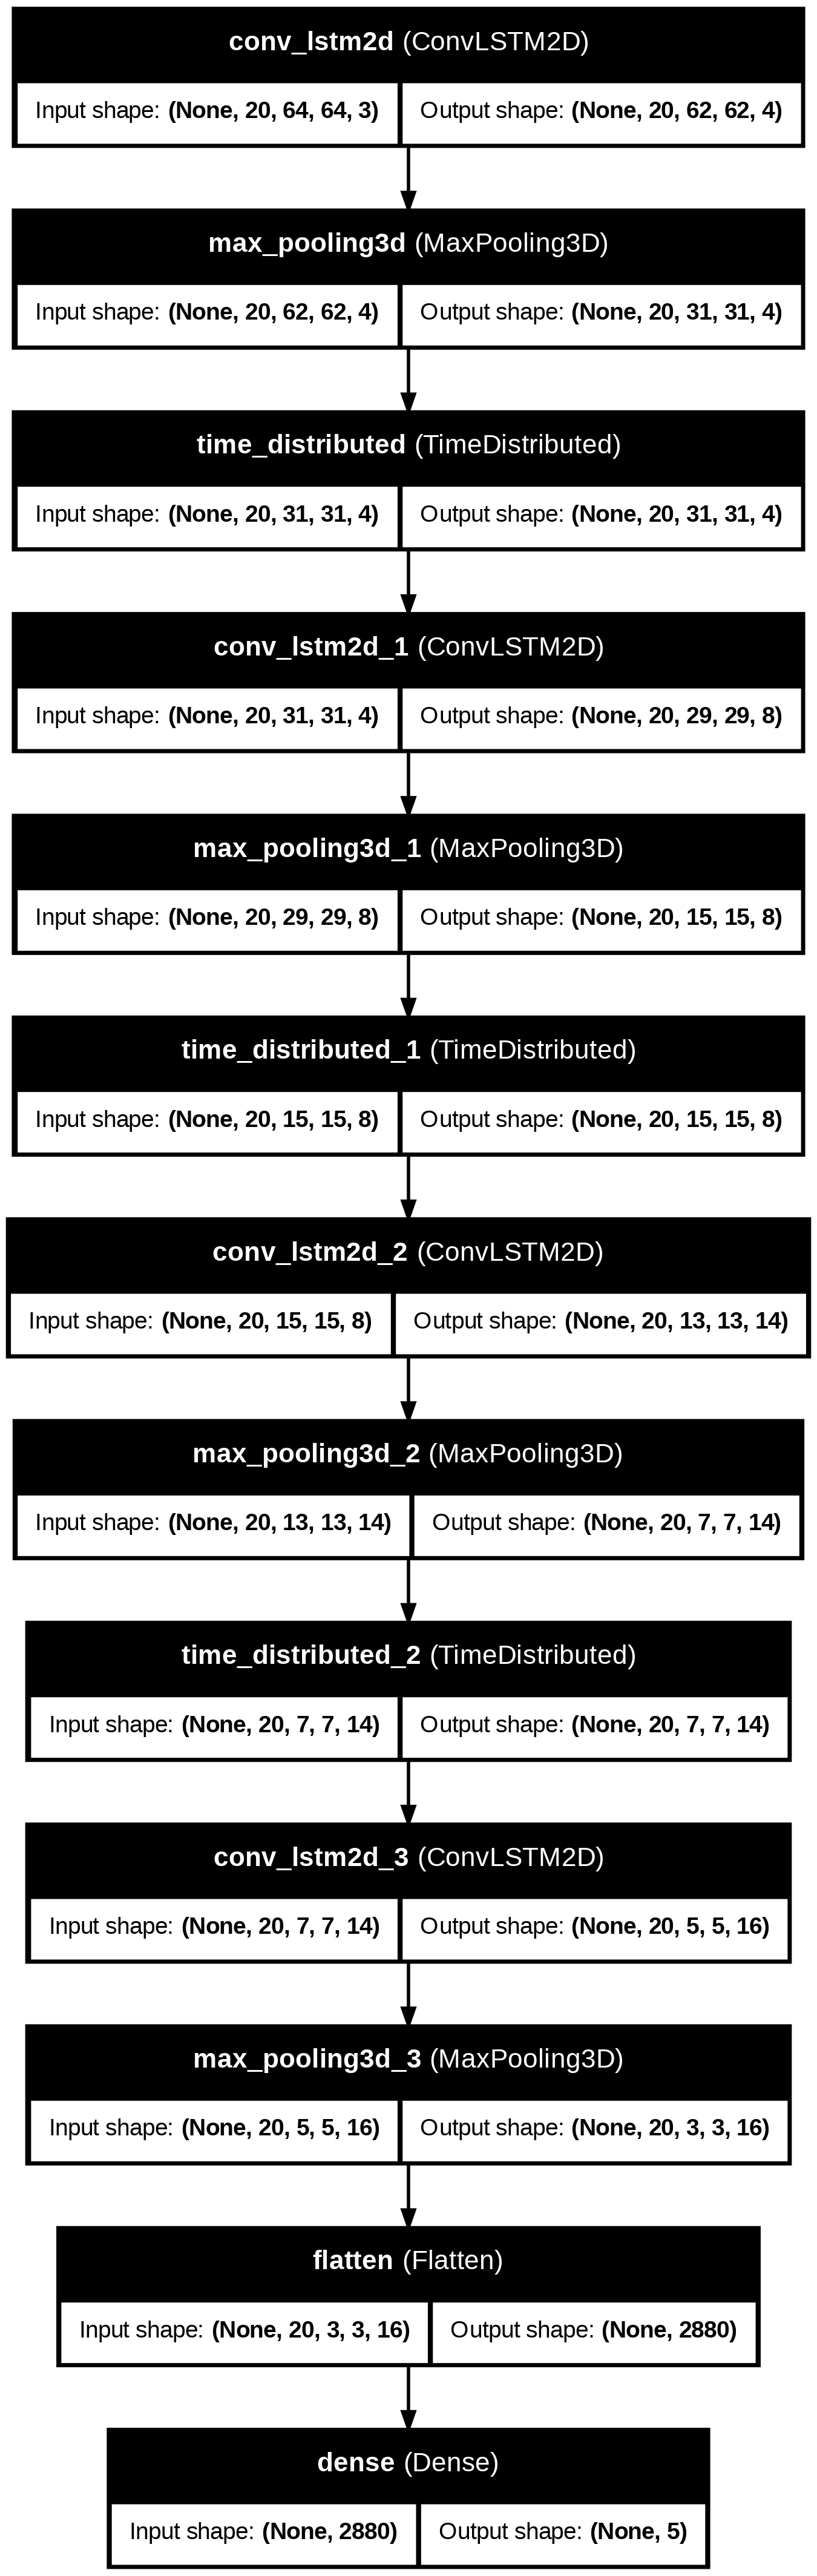

In [13]:
from tensorflow.keras.utils import plot_model
plot_model(convlstm_model, to_file = 'convlstm_model_structure_plot.png', show_shapes = True, show_layer_names = True)

In [14]:
# Create an Instance of Early Stopping Callback
early_stopping_callback = EarlyStopping(monitor = 'val_loss', patience = 10, mode = 'min', restore_best_weights = True)

# Compile the model and specify loss function, optimizer and metrics values to the model
convlstm_model.compile(loss = 'categorical_crossentropy', optimizer = 'Adam', metrics = ["accuracy"])

# Start training the model.
convlstm_model_training_history = convlstm_model.fit(x = features_train, y = labels_train, epochs = 30, batch_size = 4,
                                                     shuffle = True, validation_split = 0.2,
                                                     callbacks = [early_stopping_callback])

Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 167s 2s/step - accuracy: 0.2972 - loss: 1.5474 - val_accuracy: 0.6957 - val_loss: 0.9293
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 144s 2s/step - accuracy: 0.6883 - loss: 0.8991 - val_accuracy: 0.6522 - val_loss: 0.8174
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - accuracy: 0.7407 - loss: 0.6878 - val_accuracy: 0.7826 - val_loss: 0.6195
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 199s 2s/step - accuracy: 0.8295 - loss: 0.4879 - val_accuracy: 0.7609 - val_loss: 0.5953
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 144s 2s/step - accuracy: 0.8954 - loss: 0.3183 - val_accuracy: 0.8587 - val_loss: 0.4687
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 203s 2s/step - accuracy: 0.9133 - loss: 0.2463 - val_accuracy: 0.8804 - val_loss: 0.3680
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 196s 2s/step - accuracy: 0.9504 - loss: 0.1673 - val_accuracy: 0.8804 - val_loss: 0.3216
Epoch 8/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.9257 - loss: 0.2245 - val_accuracy: 0.9022 - v

In [15]:
model_evaluation_history = convlstm_model.evaluate(features_test, labels_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - accuracy: 0.8931 - loss: 0.4175


In [ ]:
# Get the loss and accuracy from model_evaluation_history.
model_evaluation_loss, model_evaluation_accuracy = model_evaluation_history

# Define the string date format.
# Get the current Date and Time in a DateTime Object.
# Convert the DateTime object to string according to the style mentioned in date_time_format string.
date_time_format = '%Y_%m_%d__%H_%M_%S'
current_date_time_dt = dt.datetime.now()
current_date_time_string = dt.datetime.strftime(current_date_time_dt, date_time_format)

# Define a useful name for our model to make it easy for us while navigating through multiple saved models.
model_file_name = f'convlstm_model___Date_Time_{current_date_time_string}___Loss_{model_evaluation_loss}___Accuracy_{model_evaluation_accuracy}.h5'

# Save your Model.
convlstm_model.save(model_file_name)

In [17]:
def plot_metric(model_training_history, metric_name_1, metric_name_2, plot_name):
    '''
    This function will plot the metrics passed to it in a graph.
    Args:
        model_training_history: A history object containing a record of training and validation
                                loss values and metrics values at successive epochs
        metric_name_1:          The name of the first metric that needs to be plotted in the graph.
        metric_name_2:          The name of the second metric that needs to be plotted in the graph.
        plot_name:              The title of the graph.
    '''

    # Get metric values using metric names as identifiers.
    metric_value_1 = model_training_history.history[metric_name_1]
    metric_value_2 = model_training_history.history[metric_name_2]

    # Construct a range object which will be used as x-axis (horizontal plane) of the graph.
    epochs = range(len(metric_value_1))

    # Plot the Graph.
    plt.plot(epochs, metric_value_1, 'blue', label = metric_name_1)
    plt.plot(epochs, metric_value_2, 'red', label = metric_name_2)

    # Add title to the plot.
    plt.title(str(plot_name))

    # Add legend to the plot.
    plt.legend()

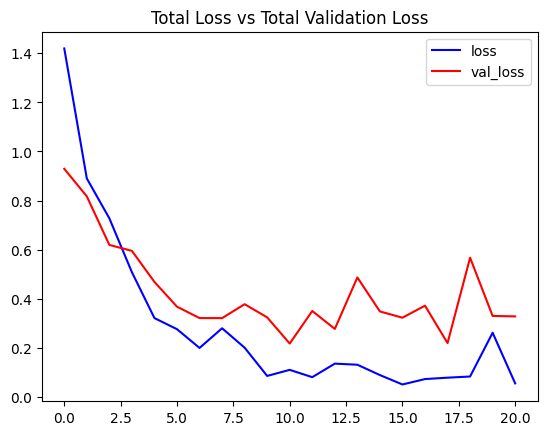

In [18]:
# Visualize the training and validation loss metrices.
plot_metric(convlstm_model_training_history, 'loss', 'val_loss', 'Total Loss vs Total Validation Loss')

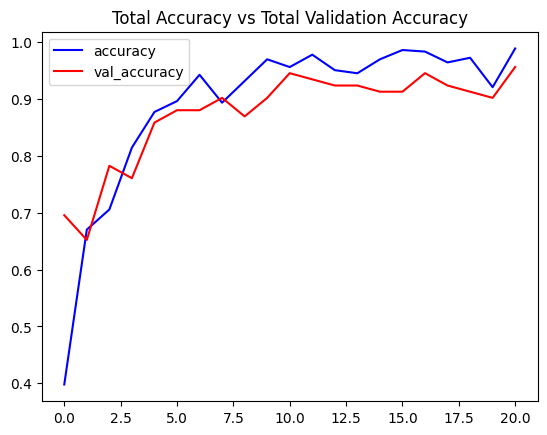

In [19]:
# Visualize the training and validation accuracy metrices.
plot_metric(convlstm_model_training_history, 'accuracy', 'val_accuracy', 'Total Accuracy vs Total Validation Accuracy')

In [20]:
def create_LRCN_model():
    '''
    This function will construct the required LRCN model.
    Returns:
        model: It is the required constructed LRCN model.
    '''

    # We will use a Sequential model for model construction.
    model = Sequential()

    # Define the Model Architecture.
    ########################################################################################################################

    model.add(TimeDistributed(Conv2D(16, (3, 3), padding='same',activation = 'relu'),
                              input_shape = (SEQUENCE_LENGTH, IMAGE_HEIGHT, IMAGE_WIDTH, 3)))

    model.add(TimeDistributed(MaxPooling2D((4, 4))))
    model.add(TimeDistributed(Dropout(0.25)))

    model.add(TimeDistributed(Conv2D(32, (3, 3), padding='same',activation = 'relu')))
    model.add(TimeDistributed(MaxPooling2D((4, 4))))
    model.add(TimeDistributed(Dropout(0.25)))

    model.add(TimeDistributed(Conv2D(64, (3, 3), padding='same',activation = 'relu')))
    model.add(TimeDistributed(MaxPooling2D((2, 2))))
    model.add(TimeDistributed(Dropout(0.25)))

    model.add(TimeDistributed(Conv2D(64, (3, 3), padding='same',activation = 'relu')))
    model.add(TimeDistributed(MaxPooling2D((2, 2))))
    #model.add(TimeDistributed(Dropout(0.25)))

    model.add(TimeDistributed(Flatten()))

    model.add(LSTM(32))

    model.add(Dense(len(CLASSES_LIST), activation = 'softmax'))

    ########################################################################################################################

    # Display the models summary.
    model.summary()

    # Return the constructed LRCN model.
    return model

In [21]:
# Construct the required LRCN model.
LRCN_model = create_LRCN_model()

# Display the success message.
print("Model Created Successfully!")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ time_distributed_3 (TimeDistributed) │ (None, 20, 64, 64, 16)      │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_4 (TimeDistributed) │ (None, 20, 16, 16, 16)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_5 (TimeDistributed) │ (None, 20, 16, 16, 16)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_6 (TimeDistributed) │ (None, 20, 16, 16, 32)      │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_7 (TimeDistributed) │ (None, 20, 4, 4, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_8 (TimeDistributed) │ (None, 20, 4, 4, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_9 (TimeDistributed) │ (None, 20, 4, 4, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_10                  │ (None, 20, 2, 2, 64)        │               0 │
│ (TimeDistributed)                    │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_11                  │ (None, 20, 2, 2, 64)        │               0 │
│ (TimeDistributed)                    │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_12                  │ (None, 20, 2, 2, 64)        │          36,928 │
│ (TimeDistributed)                    │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_13                  │ (None, 20, 1, 1, 64)        │               0 │
│ (TimeDistributed)                    │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_14                  │ (None, 20, 64)              │               0 │
│ (TimeDistributed)                    │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │             165 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 73,093 (285.52 KB)

 Trainable params: 73,093 (285.52 KB)

 Non-trainable params: 0 (0.00 B)

Model Created Successfully!


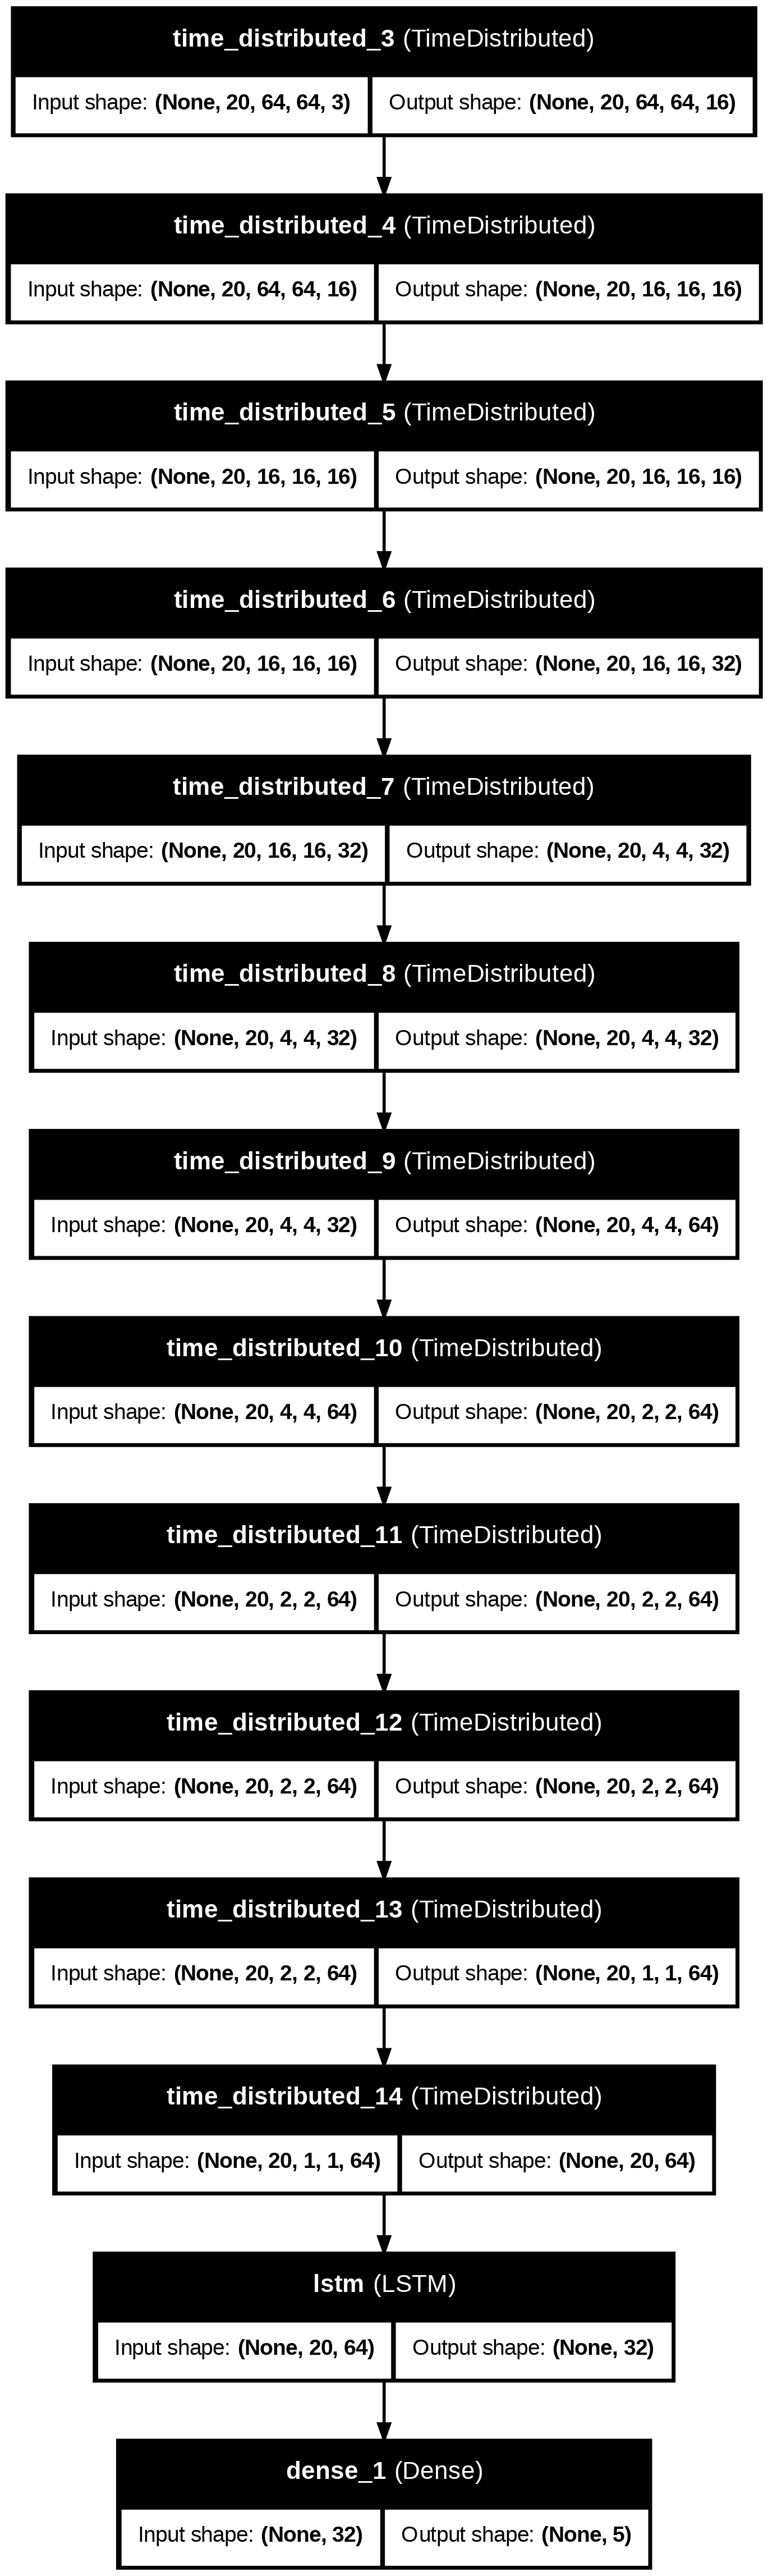

In [22]:
# Plot the structure of the contructed LRCN model.
plot_model(LRCN_model, to_file = 'LRCN_model_structure_plot.png', show_shapes = True, show_layer_names = True)

In [23]:
# Create an Instance of Early Stopping Callback.
early_stopping_callback = EarlyStopping(monitor = 'val_loss', patience = 15, mode = 'min', restore_best_weights = True)

# Compile the model and specify loss function, optimizer and metrics to the model.
LRCN_model.compile(loss = 'categorical_crossentropy', optimizer = 'Adam', metrics = ["accuracy"])

# Start training the model.
LRCN_model_training_history = LRCN_model.fit(x = features_train, y = labels_train, epochs = 40, batch_size = 4 ,
                                             shuffle = True, validation_split = 0.2, callbacks = [early_stopping_callback])

Epoch 1/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 84s 649ms/step - accuracy: 0.2216 - loss: 1.6171 - val_accuracy: 0.5217 - val_loss: 1.2606
Epoch 2/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 80s 633ms/step - accuracy: 0.3713 - loss: 1.3528 - val_accuracy: 0.4674 - val_loss: 1.0754
Epoch 3/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 83s 645ms/step - accuracy: 0.6139 - loss: 0.9388 - val_accuracy: 0.5109 - val_loss: 1.1828
Epoch 4/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 79s 611ms/step - accuracy: 0.6649 - loss: 0.8007 - val_accuracy: 0.4783 - val_loss: 1.3714
Epoch 5/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 81s 599ms/step - accuracy: 0.7776 - loss: 0.5594 - val_accuracy: 0.5217 - val_loss: 1.3093
Epoch 6/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 55s 600ms/step - accuracy: 0.7903 - loss: 0.4845 - val_accuracy: 0.4783 - val_loss: 1.5493
Epoch 7/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 85s 632ms/step - accuracy: 0.8805 - loss: 0.3849 - val_accuracy: 0.4457 - val_loss: 1.8442
Epoch 8/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 63s 690ms/step - accuracy: 0.8774 - loss: 0.3101 - val_accu

In [35]:
# Evaluate the trained model.
model_evaluation_history = LRCN_model.evaluate(features_test, labels_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 841ms/step - accuracy: 0.8531 - loss: 0.4079


In [36]:
# Get the loss and accuracy from model_evaluation_history.
model_evaluation_loss, model_evaluation_accuracy = model_evaluation_history

# Define the string date format.
# Get the current Date and Time in a DateTime Object.
# Convert the DateTime object to string according to the style mentioned in date_time_format string.
date_time_format = '%Y_%m_%d__%H_%M_%S'
current_date_time_dt = dt.datetime.now()
current_date_time_string = dt.datetime.strftime(current_date_time_dt, date_time_format)

# Define a useful name for our model to make it easy for us while navigating through multiple saved models.
model_file_name = f'LRCN_model___Date_Time_{current_date_time_string}___Loss_{model_evaluation_loss}___Accuracy_{model_evaluation_accuracy}.h5'

# Save the Model.
LRCN_model.save(model_file_name)

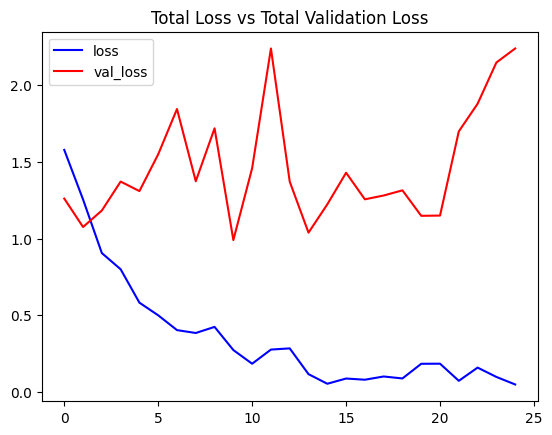

In [37]:
# Visualize the training and validation loss metrices.
plot_metric(LRCN_model_training_history, 'loss', 'val_loss', 'Total Loss vs Total Validation Loss')

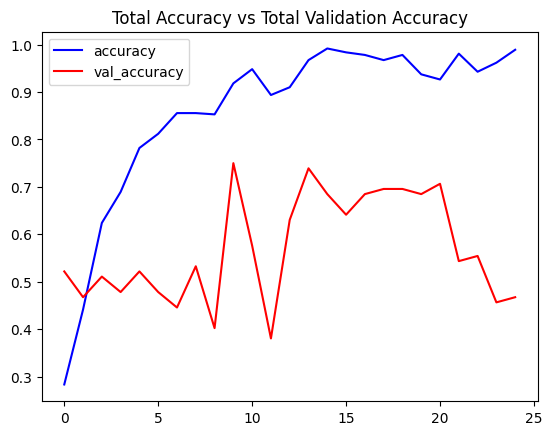

In [38]:
# Visualize the training and validation accuracy metrices.
plot_metric(LRCN_model_training_history, 'accuracy', 'val_accuracy', 'Total Accuracy vs Total Validation Accuracy')

In [40]:
import tensorflow as tf
# Load the trained model
model_path = r"/content/LRCN_model___Date_Time_2025_01_18__10_29_06___Loss_0.44868937134742737___Accuracy_0.843137264251709.h5"
model = tf.keras.models.load_model(model_path)

In [52]:
import pandas as pd

# Load the CSV file
csv_file_path = '/root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/train.csv'
data = pd.read_csv(csv_file_path)

# Display the first few rows of the dataframe
print(data.head())

         clip_name                         clip_path  label
0  v_Swing_g05_c02  /train/Swing/v_Swing_g05_c02.avi  Swing
1  v_Swing_g21_c03  /train/Swing/v_Swing_g21_c03.avi  Swing
2  v_Swing_g07_c01  /train/Swing/v_Swing_g07_c01.avi  Swing
3  v_Swing_g24_c04  /train/Swing/v_Swing_g24_c04.avi  Swing
4  v_Swing_g20_c03  /train/Swing/v_Swing_g20_c03.avi  Swing


In [55]:
import cv2
import numpy as np
import tensorflow as tf

# Load the trained model
model_path = r"/content/LRCN_model___Date_Time_2025_01_18__10_29_06___Loss_0.44868937134742737___Accuracy_0.843137264251709.h5"
model = tf.keras.models.load_model(model_path)

# Define the class names
class_names = ["CricketShot", "PlayingCello", "Punch", "ShavingBeard", "TennisSwing"]

def preprocess_video(video_path, sequence_length, height, width):
    # Capture the video
    cap = cv2.VideoCapture(video_path)
    frames = []

    while len(frames) < sequence_length:
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.resize(frame, (width, height))  # Resize frame
        frames.append(frame)

    cap.release()

    # If no frames were captured, raise an error
    if len(frames) == 0:
        raise ValueError("No frames captured from the video. Please check the video path.")

    # If we have fewer frames than sequence_length, pad with the last frame
    while len(frames) < sequence_length:
        frames.append(frames[-1])

    # Convert to numpy array and normalize
    frames = np.array(frames)
    frames = frames / 255.0  # Normalize to [0, 1]
    frames = np.expand_dims(frames, axis=0)  # Add batch dimension
    return frames

# Parameters
sequence_length = 20
height = 64
width = 64
 #Example video path (update this path according to your dataset)
example_video_path = r"/root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/train/CricketShot/v_CricketShot_g01_c01.avi"  # Replace with the actual path

# Preprocess the video
input_data = preprocess_video(example_video_path, sequence_length, height, width)

# Make predictions
predictions = model.predict(input_data)
print(predictions)

# Get the index of the highest prediction
highest_pred_index = np.argmax(predictions)

# Get the class name of the highest prediction
highest_pred_class = class_names[highest_pred_index]

# Print the highest prediction class and the corresponding probability
print(f"Highest prediction class: {highest_pred_class}, Probability: {predictions[0][highest_pred_index]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
[[0.5519642  0.00261413 0.00063164 0.07498302 0.369807  ]]
Highest prediction class: CricketShot, Probability: 0.5519642233848572


In [59]:
print(os.listdir('/root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/train/CricketShot'))


['v_CricketShot_g23_c05.avi', 'v_CricketShot_g06_c05.avi', 'v_CricketShot_g05_c06.avi', 'v_CricketShot_g01_c02.avi', 'v_CricketShot_g08_c04.avi', 'v_CricketShot_g11_c06.avi', 'v_CricketShot_g09_c03.avi', 'v_CricketShot_g10_c04.avi', 'v_CricketShot_g03_c06.avi', 'v_CricketShot_g12_c03.avi', 'v_CricketShot_g22_c04.avi', 'v_CricketShot_g16_c05.avi', 'v_CricketShot_g23_c02.avi', 'v_CricketShot_g24_c02.avi', 'v_CricketShot_g02_c07.avi', 'v_CricketShot_g06_c06.avi', 'v_CricketShot_g14_c07.avi', 'v_CricketShot_g15_c02.avi', 'v_CricketShot_g25_c01.avi', 'v_CricketShot_g09_c05.avi', 'v_CricketShot_g17_c01.avi', 'v_CricketShot_g03_c02.avi', 'v_CricketShot_g04_c05.avi', 'v_CricketShot_g10_c03.avi', 'v_CricketShot_g11_c03.avi', 'v_CricketShot_g08_c02.avi', 'v_CricketShot_g18_c02.avi', 'v_CricketShot_g13_c01.avi', 'v_CricketShot_g13_c07.avi', 'v_CricketShot_g25_c02.avi', 'v_CricketShot_g03_c05.avi', 'v_CricketShot_g07_c06.avi', 'v_CricketShot_g02_c04.avi', 'v_CricketShot_g04_c07.avi', 'v_CricketSho

In [60]:
import os
import cv2
import numpy as np
import tensorflow as tf

# Load the trained model
model_path = r"/content/LRCN_model___Date_Time_2025_01_18__10_29_06___Loss_0.44868937134742737___Accuracy_0.843137264251709.h5"
model = tf.keras.models.load_model(model_path)

# Define the class names
class_names = ["CricketShot", "PlayingCello", "Punch", "ShavingBeard", "TennisSwing"]

def preprocess_video(video_path, sequence_length, height, width):
    # Capture the video
    cap = cv2.VideoCapture(video_path)
    frames = []

    while len(frames) < sequence_length:
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.resize(frame, (width, height))  # Resize frame
        frames.append(frame)

    cap.release()

    # If no frames were captured, raise an error
    if len(frames) == 0:
        raise ValueError("No frames captured from the video. Please check the video path.")

    # If we have fewer frames than sequence_length, pad with the last frame
    while len(frames) < sequence_length:
        frames.append(frames[-1])

    # Convert to numpy array and normalize
    frames = np.array(frames)
    frames = frames / 255.0  # Normalize to [0, 1]
    frames = np.expand_dims(frames, axis=0)  # Add batch dimension
    return frames
def evaluate_model(model, test_dir, sequence_length, height, width, class_names):
    correct_predictions = 0
    total_predictions = 0

    for label_name in class_names:
        video_dir = os.path.join(test_dir, label_name)
        for video_name in os.listdir(video_dir):
            video_path = os.path.join(video_dir, video_name)
            true_label = label_name

            try:
                input_data = preprocess_video(video_path, sequence_length, height, width)
                predictions = model.predict(input_data)
                highest_pred_index = np.argmax(predictions)
                predicted_class = class_names[highest_pred_index]

                print(f"Video: {video_path}, Predicted: {predicted_class}, True: {true_label}, Probability: {predictions[0][highest_pred_index]}")

                if predicted_class == true_label:
                    correct_predictions += 1
                total_predictions += 1
            except Exception as e:
                print(f"Error processing video {video_path}: {e}")

    accuracy = correct_predictions / total_predictions
    return accuracy

# Parameters
sequence_length = 20
height = 64
width = 64

# Test directory
test_dir = r"/root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/test"

# Evaluate the model
accuracy = evaluate_model(model, test_dir, sequence_length, height, width, class_names)
print(f"Model accuracy on test data: {accuracy * 100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Video: /root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/test/CricketShot/v_CricketShot_g03_c07.avi, Predicted: TennisSwing, True: CricketShot, Probability: 0.9902412295341492
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
Video: /root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/test/CricketShot/v_CricketShot_g22_c03.avi, Predicted: ShavingBeard, True: CricketShot, Probability: 0.6981964111328125
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Video: /root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/test/CricketShot/v_CricketShot_g16_c06.avi, Predicted: CricketShot, True: CricketShot, Probability: 0.6370900869369507
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Video: /root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/test/CricketShot/v_CricketShot_g02_c03.avi, Predicted: CricketShot, True: CricketShot, Probability: 0.9336016774177551
1/1 ━━━━━━━━━

In [61]:
from sklearn.metrics import classification_report

In [63]:
import os
import cv2
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report

# Load the trained model
model_path = r"/content/LRCN_model___Date_Time_2025_01_18__10_29_06___Loss_0.44868937134742737___Accuracy_0.843137264251709.h5"
model = tf.keras.models.load_model(model_path)

# Define the class names
class_names = ["CricketShot", "PlayingCello", "Punch", "ShavingBeard", "TennisSwing"]

def preprocess_video(video_path, sequence_length, height, width):
    # Capture the video
    cap = cv2.VideoCapture(video_path)
    frames = []

    while len(frames) < sequence_length:
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.resize(frame, (width, height))  # Resize frame
        frames.append(frame)

    cap.release()

    # If no frames were captured, raise an error
    if len(frames) == 0:
        raise ValueError("No frames captured from the video. Please check the video path.")

    # If we have fewer frames than sequence_length, pad with the last frame
    while len(frames) < sequence_length:
        frames.append(frames[-1])

    # Convert to numpy array and normalize
    frames = np.array(frames)
    frames = frames / 255.0  # Normalize to [0, 1]
    frames = np.expand_dims(frames, axis=0)  # Add batch dimension
    return frames
def evaluate_model(model, test_dir, sequence_length, height, width, class_names):
    y_true = []
    y_pred = []

    for label_name in class_names:
        video_dir = os.path.join(test_dir, label_name)
        for video_name in os.listdir(video_dir):
            video_path = os.path.join(video_dir, video_name)
            true_label_index = class_names.index(label_name)

            try:
                input_data = preprocess_video(video_path, sequence_length, height, width)
                predictions = model.predict(input_data)
                highest_pred_index = np.argmax(predictions)
                predicted_class_index = highest_pred_index

                y_true.append(true_label_index)
                y_pred.append(predicted_class_index)

                print(f"Video: {video_path}, Predicted: {class_names[predicted_class_index]}, True: {class_names[true_label_index]}, Probability: {predictions[0][highest_pred_index]}")
            except Exception as e:
                print(f"Error processing video {video_path}: {e}")

    return y_true, y_pred

# Parameters
sequence_length = 20
height = 64
width = 64

# Test directory
test_dir = r"/root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/test"

# Evaluate the model and get true and predicted labels
y_true, y_pred = evaluate_model(model, test_dir, sequence_length, height, width, class_names)

# Generate classification report
report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:\n")
print(report)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Video: /root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/test/CricketShot/v_CricketShot_g03_c07.avi, Predicted: TennisSwing, True: CricketShot, Probability: 0.9902412295341492
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Video: /root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/test/CricketShot/v_CricketShot_g22_c03.avi, Predicted: ShavingBeard, True: CricketShot, Probability: 0.6981964111328125
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Video: /root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/test/CricketShot/v_CricketShot_g16_c06.avi, Predicted: CricketShot, True: CricketShot, Probability: 0.6370900869369507
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Video: /root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/test/CricketShot/v_CricketShot_g02_c03.avi, Predicted: CricketShot, True: CricketShot, Probability: 0.9336016774177551
1/1 ━━━━━━━━━